# 04 Coach Annual Simulation

## 0. 这个 notebook 在做什么

本页解释 coach annual simulation 如何把 TransXChange (TxC) coach journeys 转成 feed-year synthetic charging demand，研究问题是：在没有真实 coach vehicle blocking 的情况下，能否构造一个透明的年度 SOC/load layer，用来审计 coach electrification 的能量规模与 synthetic terminus capacity。

方法骨架是 `TxC inventory -> TxC XML per service -> operating profile -> vehicle journey -> journey_id -> coach_chain_id -> DailySchedule -> feed-year expansion -> SOC/load profile`。与 bus 的 `block_id` 不同，`coach_chain_id` 是本 simulation 用 first-fit heuristic 构造出来的，不是数据源给出的真实 operator 车辆排班。

关键 caveat 是 feed-year 来自 TxC operating periods，notebook 使用 small smoke chains 和 `warm_up_days=0` 以便快速执行；production annual runs 应使用 `WARMUP_DAYS=14` 或更长。`terminus_charge_kw` 表示车辆回到一个能慢充的终点站；trip 间 layover charging 默认关闭。E.5 的 LSOA terminus capacity 是从 simulation 反推的 synthetic map，不是真实 depot 或公共充电桩 inventory。

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NOTEBOOK_START = time.time()
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "mobility").exists() else NOTEBOOK_DIR.parent
if not (REPO_ROOT / "mobility").exists():
    REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
scripts_dir = REPO_ROOT / "scripts"
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from mobility.core.constants import STEP_HOURS_DECISION, STEPS_PER_DAY_DECISION, WARMUP_DAYS
from mobility.coach.annual_simulation import simulate_coach_chain_year
from mobility.coach.calendar import (
    COACH_FEED_YEAR_END,
    COACH_FEED_YEAR_START,
    build_journey_date_index,
)
from mobility.coach.chain_builder import build_coach_chains
from mobility.coach.coach_fleet import COACH_FLEET_PATH
from mobility.coach.data_loader import (
    DEFAULT_COACH_ROOT,
    DEFAULT_JOURNEYS_PATH,
    DEFAULT_STOP_SEQUENCES_PATH,
)
from mobility.coach.feasibility import journey_feasibility
from mobility.coach.lsoa_attribution import chain_home_lsoa, lsoa_view
from mobility.coach.sim_adapter import DEFAULT_TERMINUS_CHARGE_KW
from mobility.coach.stop_geometry import attach_lsoa_to_journeys
from mobility.coach.year_schedule import annual_dates, chain_to_year_schedules
from run_coach_annual_pipeline import run_pipeline

CHAIN_LIMIT = 8
WARM_UP_DAYS_SMOKE = 0
MAIN_COACH_ANNUAL_SEED = 20260513
SMOKE_JOURNEYS_PATH = REPO_ROOT / "outputs" / "coach_annual_smoke_input_journeys.parquet"
SMOKE_STOPS_PATH = REPO_ROOT / "outputs" / "coach_annual_smoke_input_stops.parquet"
COACH_ANNUAL_SMOKE_PER_CHAIN_PATH = REPO_ROOT / "outputs" / "coach_annual_smoke_per_chain.parquet"
COACH_ANNUAL_SMOKE_LOAD_PROFILE_PATH = REPO_ROOT / "outputs" / "coach_annual_smoke_load_profile.parquet"

plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
def _endpoint_coordinates(stop_sequences):
    rows = []
    if stop_sequences.empty:
        return pd.DataFrame(columns=["journey_id", "start_lat", "start_lon", "end_lat", "end_lon"])
    for journey_id, group in stop_sequences.groupby("journey_id", sort=False):
        ordered = group.sort_values("stop_sequence", kind="stable")
        first = ordered.iloc[0]
        last = ordered.iloc[-1]
        rows.append(
            {
                "journey_id": str(journey_id),
                "start_lat": first.get("lat"),
                "start_lon": first.get("lon"),
                "end_lat": last.get("lat"),
                "end_lon": last.get("lon"),
            }
        )
    return pd.DataFrame(rows)


def ensure_smoke_outputs():
    if not SMOKE_JOURNEYS_PATH.exists() or not SMOKE_STOPS_PATH.exists():
        raw_journeys = pd.read_parquet(DEFAULT_JOURNEYS_PATH)
        raw_stops = pd.read_parquet(DEFAULT_STOP_SEQUENCES_PATH)
        known = raw_journeys[pd.to_numeric(raw_journeys["distance_km"], errors="coerce").notna()].copy()
        known = known.sort_values(["operator_code", "start_h", "end_h", "journey_id"], kind="stable").head(36)
        keep_ids = set(known["journey_id"].astype(str))
        stop_subset = raw_stops[raw_stops["journey_id"].astype(str).isin(keep_ids)].copy()
        prepared = known.merge(_endpoint_coordinates(stop_subset), on="journey_id", how="left")
        try:
            prepared = attach_lsoa_to_journeys(prepared)
        except Exception:
            prepared["start_lsoa"] = prepared.get("start_stop_ref", pd.Series("", index=prepared.index)).astype(str)
            prepared["end_lsoa"] = prepared.get("end_stop_ref", pd.Series("", index=prepared.index)).astype(str)
        SMOKE_JOURNEYS_PATH.parent.mkdir(parents=True, exist_ok=True)
        prepared.to_parquet(SMOKE_JOURNEYS_PATH, index=False)
        stop_subset.to_parquet(SMOKE_STOPS_PATH, index=False)

    run_pipeline(
        journeys_parquet=SMOKE_JOURNEYS_PATH,
        stop_sequences_parquet=SMOKE_STOPS_PATH,
        fleet_path=COACH_FLEET_PATH,
        per_chain_out=COACH_ANNUAL_SMOKE_PER_CHAIN_PATH,
        load_profile_out=COACH_ANNUAL_SMOKE_LOAD_PROFILE_PATH,
        seed=MAIN_COACH_ANNUAL_SEED,
        warm_up_days=WARM_UP_DAYS_SMOKE,
        limit=CHAIN_LIMIT,
        n_workers=1,
    )


ensure_smoke_outputs()
journeys_smoke = pd.read_parquet(SMOKE_JOURNEYS_PATH)
per_chain = pd.read_parquet(COACH_ANNUAL_SMOKE_PER_CHAIN_PATH)
load_profile = pd.read_parquet(COACH_ANNUAL_SMOKE_LOAD_PROFILE_PATH)
display(
    pd.DataFrame(
        [
            ("feed_year_start", COACH_FEED_YEAR_START.isoformat()),
            ("feed_year_end", COACH_FEED_YEAR_END.isoformat()),
            ("smoke_chains", len(per_chain)),
            ("warm_up_days_smoke", WARM_UP_DAYS_SMOKE),
            ("warm_up_days_production", WARMUP_DAYS),
        ],
        columns=["metric", "value"],
    )
)

,metric,value
0,feed_year_start,2025-12-26
1,feed_year_end,2026-12-25
2,smoke_chains,8
3,warm_up_days_smoke,0
4,warm_up_days_production,14


## A. TxC Operating Profile -> Feed-Year Calendar

本段解释 TxC `OperatingProfile` 如何变成 per-journey active dates。Coach XML 有些 journey 明确给出 day-of-week 或 holiday-only service，有些缺 profile；缺失时本 notebook 使用 `fallback_uniform`，并把这个来源作为审计列展示。

,profile_source,rows
0,txc,2296


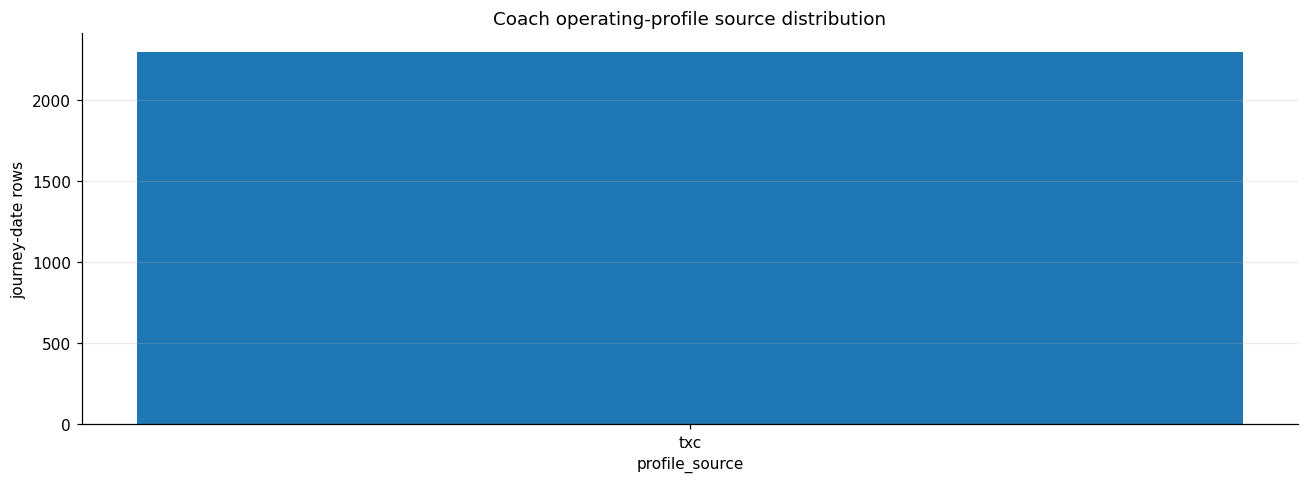

In [3]:
date_index = build_journey_date_index(journeys_smoke, DEFAULT_COACH_ROOT)
source_counts = date_index["profile_source"].value_counts().rename_axis("profile_source").reset_index(name="rows")
display(source_counts)

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
ax.bar(source_counts["profile_source"], source_counts["rows"], color=["tab:blue", "tab:orange"][: len(source_counts)])
ax.set(title="Coach operating-profile source distribution", xlabel="profile_source", ylabel="journey-date rows")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## A.5 出行模型逻辑

本段解释 coach 出行模型的概念阶梯。Bus 的 `block_id` 是 GTFS 数据自带的真实 operator 排班；coach 的 `coach_chain_id` 是本 simulation 构造的 first-fit chain，它只表示同一假想车辆在一天里可串联的一组 journeys，不代表真实 coach operator 的车辆运营计划。

概念阶梯是 `TxC inventory (CSV) -> TxC XML per service -> operating profile -> vehicle journey -> journey_id -> coach_chain_id -> DailySchedule -> 年度展开`。这个 caveat 会降低后面 home LSOA / synthetic terminus attribution 的可信度：bus 可用真实 block 反推 depot，coach 只能用假想 chain 的 end LSOA 做 post-hoc 归因。

,chain_id,n_active_days,n_journey_rows,n_template_journeys
12,FLIX_4943e30ced,183,183,1
11,FLIX_48fa7d50ee,168,168,1
34,FLIX_fe526deb79,168,168,1
0,BHAT_08359e61d2,145,290,2
10,FLIX_43a8975bdb,138,138,1
29,FLIX_d85025a7eb,138,138,1
23,FLIX_8f0f26043e,131,131,1
4,FLIX_38943abf20,120,120,1
5,FLIX_3973275071,107,107,1
17,FLIX_713e56794e,107,107,1


,journey_id,vehicle_journey_code,start_h,end_h,distance_km,start_lsoa,end_lsoa
0,FLIX-FlixBus-UK910-Swansea-Bristol_Airport.xml...,VJ28,0.5,3.416667,150.673411,W01001997,E01014848


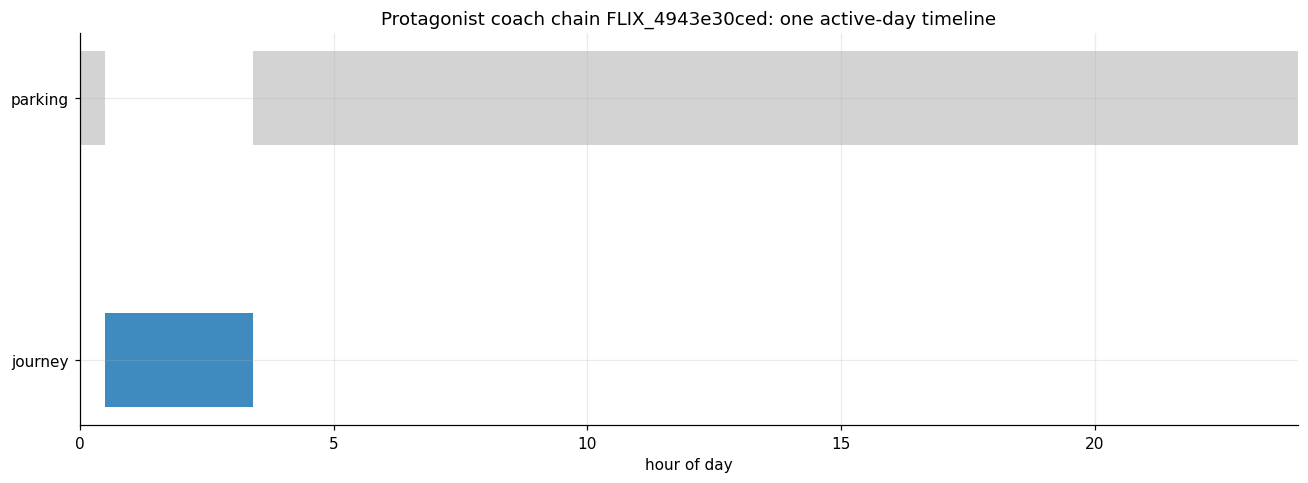

In [4]:
chains_smoke = build_coach_chains(journeys_smoke, date_index)
chain_group_col = "coach_chain_template_id" if "coach_chain_template_id" in chains_smoke.columns else "coach_chain_id"
chain_stats = (
    chains_smoke.groupby(chain_group_col)
    .agg(n_active_days=("date", "nunique"), n_journey_rows=("journey_id", "count"), n_template_journeys=("journey_id", "nunique"))
    .reset_index()
    .rename(columns={chain_group_col: "chain_id"})
)
display(chain_stats.sort_values(["n_active_days", "n_template_journeys"], ascending=False).head(10))

protagonist_id = chain_stats.sort_values(["n_active_days", "n_template_journeys"], ascending=False)["chain_id"].iloc[0]
protagonist_chain_rows = chains_smoke[chains_smoke[chain_group_col].astype(str).eq(str(protagonist_id))]
protagonist_journeys = (
    protagonist_chain_rows.sort_values(["position_in_chain", "journey_id"], kind="stable")
    .drop_duplicates("journey_id")
    .merge(journeys_smoke, on="journey_id", how="left")
)
display(
    protagonist_journeys[
        ["journey_id", "vehicle_journey_code", "start_h", "end_h", "distance_km", "start_lsoa", "end_lsoa"]
    ].head(3)
)

active_date = sorted(protagonist_chain_rows["date"].unique())[0]
consumption = float(per_chain.loc[per_chain["chain_id"].astype(str).eq(str(protagonist_id)), "consumption_kwh_per_km"].iloc[0])
timeline_schedules = chain_to_year_schedules(
    protagonist_journeys,
    [active_date],
    consumption_kwh_per_km=consumption,
    terminus_charge_kw=DEFAULT_TERMINUS_CHARGE_KW,
)
one_day = next(schedule for schedule in timeline_schedules if schedule.date == active_date)
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
for trip in one_day.trips:
    ax.barh(0, trip.arrival_time - trip.departure_time, left=trip.departure_time, height=0.36, color="tab:blue", alpha=0.86)
for park in one_day.parking_events:
    ax.barh(1, park.end_time - park.start_time, left=park.start_time, height=0.36, color="lightgray")
ax.set_yticks([0, 1])
ax.set_yticklabels(["journey", "parking"])
ax.set(title=f"Protagonist coach chain {protagonist_id}: one active-day timeline", xlabel="hour of day", xlim=(0, 24))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## B. Pick a Protagonist Chain

本段选择一个 protagonist chain 作为年度 SOC 故事线。选择标准是 active days 尽量多、template journey 数在 smoke 样本里可读；如果真实全量运行中存在 200-300 active-day chain，应优先选这种中等频率服务，当前 smoke 样本只用于教学执行速度。

In [5]:
protagonist_record = per_chain[per_chain["chain_id"].astype(str).eq(str(protagonist_id))].iloc[0]
display(
    pd.DataFrame(
        [
            ("chain_id", protagonist_id),
            ("ev_id", protagonist_record["ev_id"]),
            ("n_active_days", int(protagonist_record["n_active_days"])),
            ("total_kwh", float(protagonist_record["total_kwh"])),
            ("energy_charged_kwh", float(protagonist_record["energy_charged_kwh"])),
            ("feasible", bool(protagonist_record["feasible"])),
        ],
        columns=["field", "value"],
    )
)

,field,value
0,chain_id,FLIX_4943e30ced
1,ev_id,coach_9
2,n_active_days,183
3,total_kwh,22334.319725
4,energy_charged_kwh,22615.319725
5,feasible,True


## B.5 充电逻辑

本段解释 coach 版本的最小物理递推：$SOC_{t+1} = \mathrm{clip}\left[SOC_t - \frac{E_{journey,t}}{B} + \frac{P_{park,t} \cdot \Delta t}{B},\ 0,\ 1\right]$。`terminus_charge_kw` 表示车辆回到一个能慢充的 `depot_terminus`；同一天 trip 之间是 `layover`，默认不充电。公共 OCM eligible layover retry 是 CLI opt-in，不改变 baseline smoke run。

In [6]:
battery_kwh = float(protagonist_record["battery_kwh"])
param_table = pd.DataFrame(
    [
        ("battery_kwh", battery_kwh, "sampled coach EV spec from EV_UK_LSOA_2025_with_energy.csv"),
        ("consumption_kwh_per_km", consumption, "derived from efficiency_wh_per_km / 1000 in coach_fleet.py"),
        ("terminus_charge_kw", DEFAULT_TERMINUS_CHARGE_KW, "mobility/coach/sim_adapter.py:DEFAULT_TERMINUS_CHARGE_KW"),
        ("pre_journey_dwell_h", 6.0, "coach annual/year schedule default"),
        ("soc_init", "None -> auto-derived", "1 - pre_journey_dwell_h * terminus_charge_kw / battery_kwh"),
        ("warm_up_days", WARM_UP_DAYS_SMOKE, f"smoke setting; production annual default should use WARMUP_DAYS={WARMUP_DAYS}"),
    ],
    columns=["parameter", "value", "source"],
)
display(param_table)

max_distance = float(pd.to_numeric(protagonist_journeys["distance_km"], errors="coerce").max())
feasibility = journey_feasibility(max_distance, battery_kwh=battery_kwh, consumption_kwh_per_km=consumption)
reasons = pd.DataFrame(
    [
        ("single_charge_shortfall", "feasible_single_charge / shortfall_kwh", feasibility["feasible_single_charge"], feasibility["shortfall_kwh"]),
        ("soc_floor_hit", "soc_floor_hit_h_min", pd.isna(protagonist_record["soc_floor_hit_h_min"]), protagonist_record["soc_floor_hit_h_min"]),
        ("missing_distance", "distance_km", protagonist_journeys["distance_km"].notna().all(), int(protagonist_journeys["distance_km"].isna().sum())),
        ("simulation_error", "simulation_error", protagonist_record.get("simulation_error", "") == "", protagonist_record.get("simulation_error", "")),
    ],
    columns=["infeasibility_class", "actual_field", "passes_check", "audit_value"],
)
display(reasons)

,parameter,value,source
0,battery_kwh,281.0,sampled coach EV spec from EV_UK_LSOA_2025_wit...
1,consumption_kwh_per_km,0.81,derived from efficiency_wh_per_km / 1000 in co...
2,terminus_charge_kw,50.0,mobility/coach/sim_adapter.py:DEFAULT_TERMINUS...
3,pre_journey_dwell_h,6.0,coach annual/year schedule default
4,soc_init,None -> auto-derived,1 - pre_journey_dwell_h * terminus_charge_kw /...
5,warm_up_days,0,smoke setting; production annual default shoul...


,infeasibility_class,actual_field,passes_check,audit_value
0,single_charge_shortfall,feasible_single_charge / shortfall_kwh,True,0.0
1,soc_floor_hit,soc_floor_hit_h_min,True,NaN
2,missing_distance,distance_km,True,0
3,simulation_error,simulation_error,True,


## C. Single Chain Annual SOC

本段展示 protagonist chain 的 feed-year SOC trajectory。Smoke run 使用 `warm_up_days=0`，所以第一个 active day 仍受初始 SOC 假设影响；图中的任何 SOC floor 或 high-load day 都应按 small-sample audit 解读。

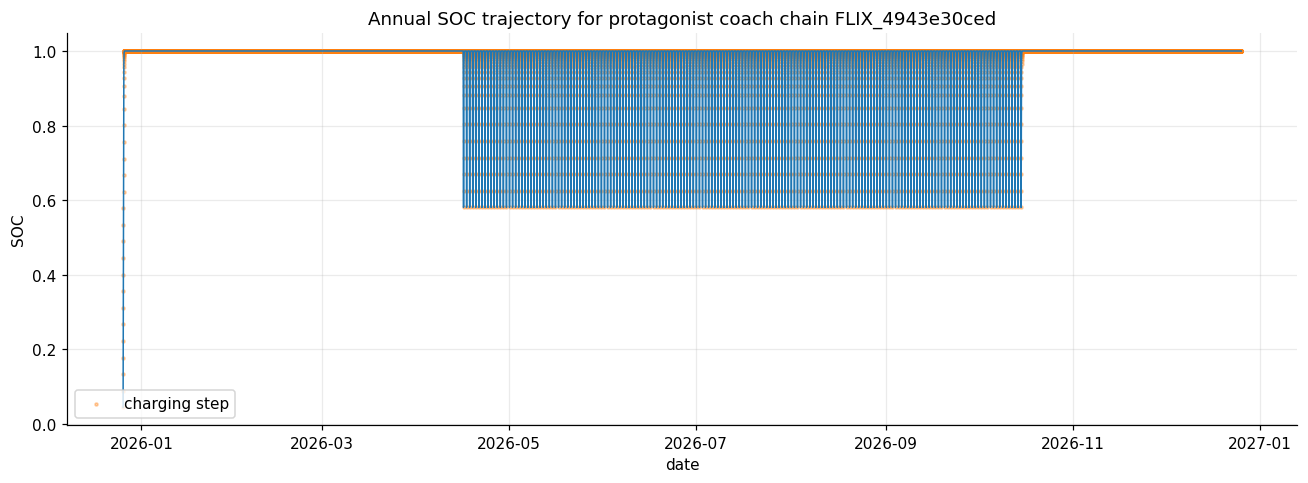

In [7]:
ev_spec = {
    "EV_ID": protagonist_record["ev_id"],
    "Energy_kWh": battery_kwh,
    "consumption_kwh_per_km": consumption,
}
protagonist_result = simulate_coach_chain_year(
    str(protagonist_id),
    protagonist_journeys,
    ev_spec,
    sorted(protagonist_chain_rows["date"].unique()),
    warm_up_days=WARM_UP_DAYS_SMOKE,
    terminus_charge_kw=DEFAULT_TERMINUS_CHARGE_KW,
)
dates = annual_dates()
time_index = pd.date_range(dates[0], periods=len(protagonist_result["soc"]), freq="15min")
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
ax.plot(time_index, protagonist_result["soc"], lw=1.0, color="tab:blue")
active_load = protagonist_result["load_kw"] > 0
ax.scatter(time_index[active_load], protagonist_result["soc"][active_load], s=4, color="tab:orange", alpha=0.35, label="charging step")
ax.set(title=f"Annual SOC trajectory for protagonist coach chain {protagonist_id}", xlabel="date", ylabel="SOC")
ax.legend(loc="lower left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## D. Small Fleet Annual Load

本段把 smoke fleet 的 chain-level load profiles 聚合成年度负荷切片。Heatmap 只展示前 7 天的 24h shape，月度柱图展示这个 small sample 的累计 charging energy；两者都不是 full national coach demand。

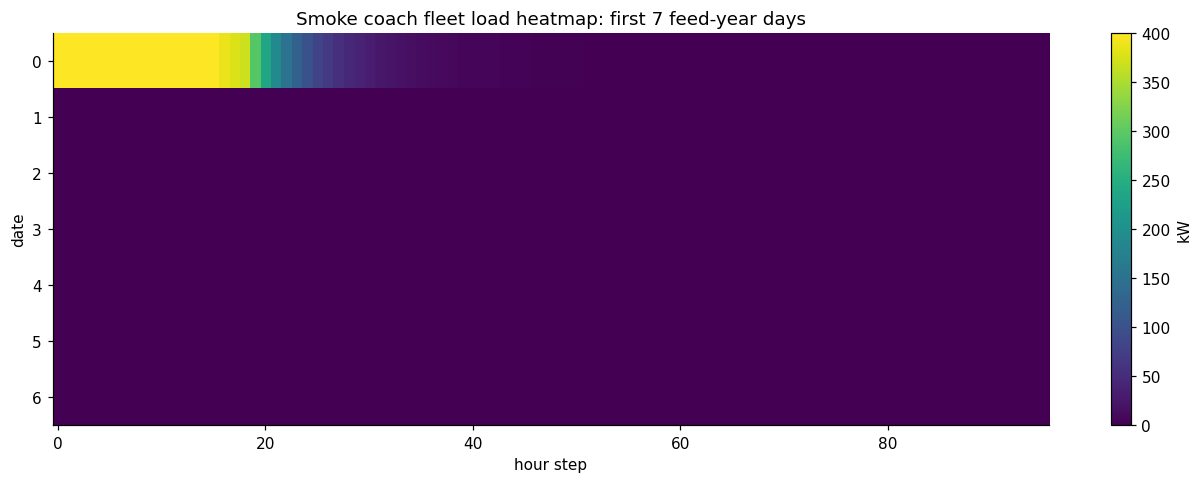

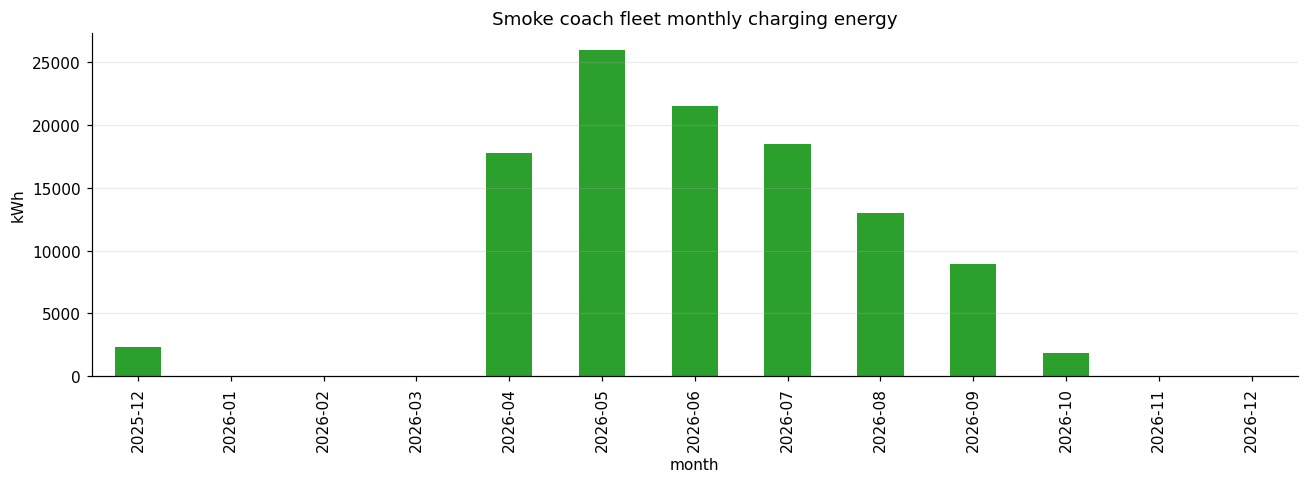

In [8]:
load_profile["date"] = pd.to_datetime(load_profile["date"])
load_profile["energy_kwh"] = load_profile["load_kw"] * STEP_HOURS_DECISION
fleet_load = load_profile.groupby(["date", "step", "hour"], as_index=False)["load_kw"].sum()
first_week = fleet_load[fleet_load["date"].isin(sorted(fleet_load["date"].unique())[:7])]
heat = first_week.pivot_table(index="date", columns="hour", values="load_kw", aggfunc="sum").fillna(0.0)
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
im = ax.imshow(heat.to_numpy(), aspect="auto", interpolation="nearest", cmap="viridis")
ax.set(title="Smoke coach fleet load heatmap: first 7 feed-year days", xlabel="hour step", ylabel="date")
fig.colorbar(im, ax=ax, label="kW")
plt.tight_layout()
plt.show()

monthly = load_profile.groupby(load_profile["date"].dt.to_period("M"))["energy_kwh"].sum()
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
monthly.plot(kind="bar", ax=ax, color="tab:green")
ax.set(title="Smoke coach fleet monthly charging energy", xlabel="month", ylabel="kWh")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## E. Annual Story Slices

本段给出四个年度故事切片：seasonal monthly energy、weekday vs weekend、SOC 触底 chain 占比，以及 cross-midnight chain 的能耗对比。所有结论只描述当前 smoke sample 的模型行为，不能外推为全国 coach fleet 结论。

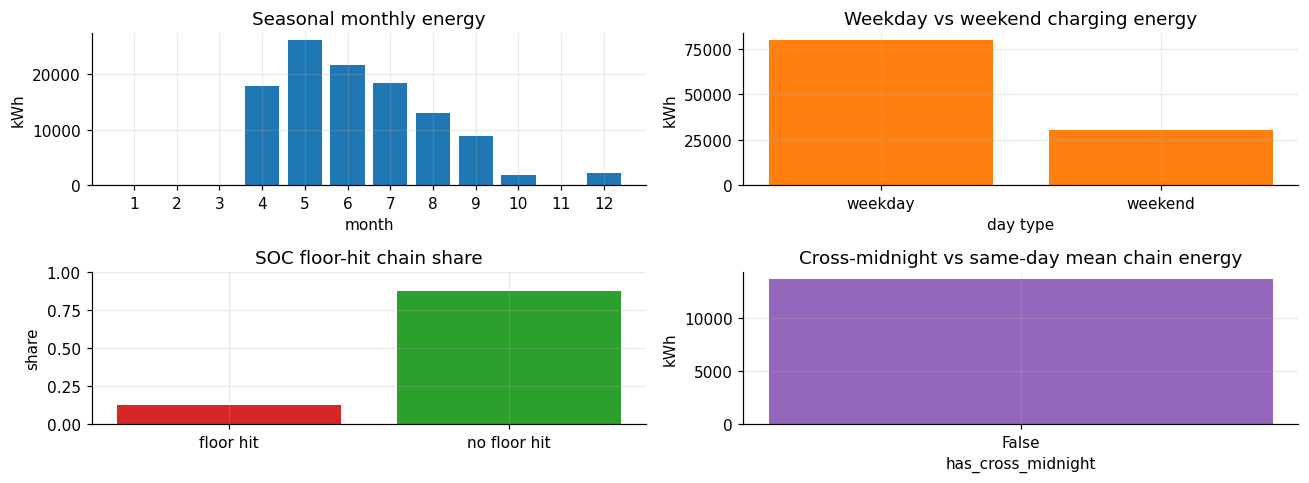

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 4.5), dpi=110)
monthly_energy = load_profile.groupby(load_profile["date"].dt.month)["energy_kwh"].sum()
axes[0, 0].bar(monthly_energy.index.astype(str), monthly_energy.values, color="tab:blue")
axes[0, 0].set(title="Seasonal monthly energy", xlabel="month", ylabel="kWh")

weekday_view = load_profile.assign(day_type=np.where(load_profile["date"].dt.weekday < 5, "weekday", "weekend"))
weekday_energy = weekday_view.groupby("day_type")["energy_kwh"].sum()
axes[0, 1].bar(weekday_energy.index, weekday_energy.values, color="tab:orange")
axes[0, 1].set(title="Weekday vs weekend charging energy", xlabel="day type", ylabel="kWh")

floor_share = float((per_chain["soc_floor_hit_h_min"].notna()).mean()) if len(per_chain) else 0.0
axes[1, 0].bar(["floor hit", "no floor hit"], [floor_share, 1.0 - floor_share], color=["tab:red", "tab:green"])
axes[1, 0].set(title="SOC floor-hit chain share", ylabel="share", ylim=(0, 1))

chain_cross = protagonist_chain_rows.groupby(chain_group_col)["journey_id"].apply(list)
cross_lookup = journeys_smoke.set_index("journey_id")["has_cross_midnight"] if "has_cross_midnight" in journeys_smoke else pd.Series(dtype=bool)
cross_flags = {
    chain_id: any(bool(cross_lookup.get(journey_id, False)) for journey_id in journey_ids)
    for chain_id, journey_ids in chain_cross.items()
}
energy_by_chain = per_chain.assign(has_cross_midnight=per_chain["chain_id"].map(cross_flags).fillna(False))
cross_energy = energy_by_chain.groupby("has_cross_midnight")["total_kwh"].mean()
axes[1, 1].bar(cross_energy.index.astype(str), cross_energy.values, color="tab:purple")
axes[1, 1].set(title="Cross-midnight vs same-day mean chain energy", xlabel="has_cross_midnight", ylabel="kWh")

for ax in axes.ravel():
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## E.5 LSOA -> Synthetic Terminus Map

本段解释 LSOA 层充电需求归因。每个 coach_chain 的 home LSOA 定义为其 feed-year 内 `end_lsoa` 的众数；该 chain 的 `terminus_charge_kw` 视为该 LSOA 内一个 synthetic terminus charger 的额定功率。LSOA terminus 总容量 = 所有 home 在该 LSOA 的 chain 的 `terminus_charge_kw` 之和。

该容量地图完全从 simulation 反推，公共充电桩（OCM）未纳入；三类放宽是 public charger eligibility、real coach depot inventory、cross-modal contention with bus/car，见 [`docs/coach_annual_next_steps.md`](../docs/coach_annual_next_steps.md)。

,lsoa_code,n_home_chains,sim_kwh_year,terminus_total_kw,ceiling_kwh_year,gap_ratio
0,unknown,8,109868.233017,400.0,3504000.0,0.031355


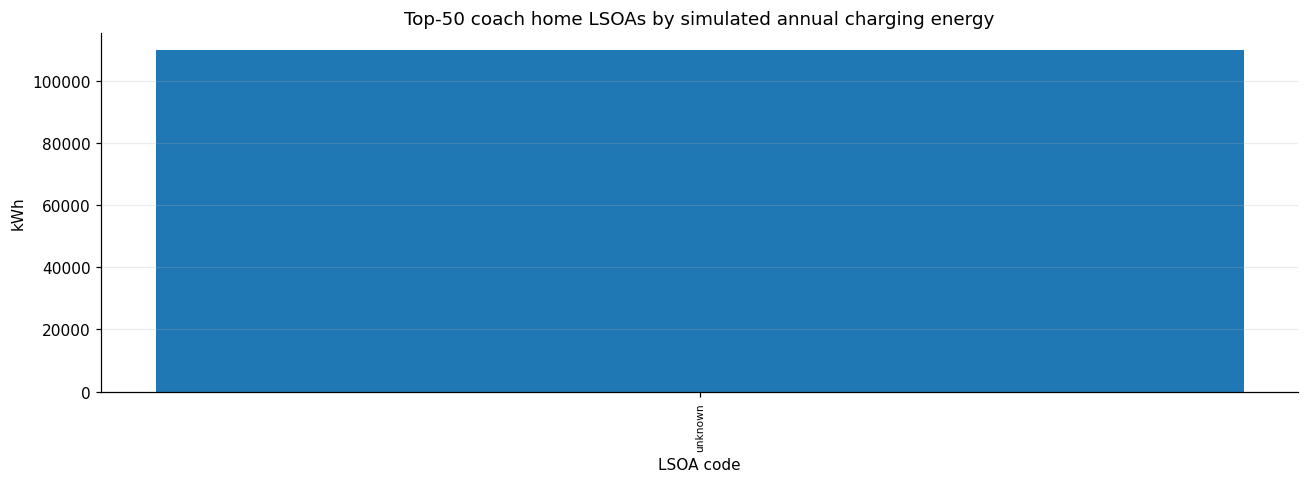

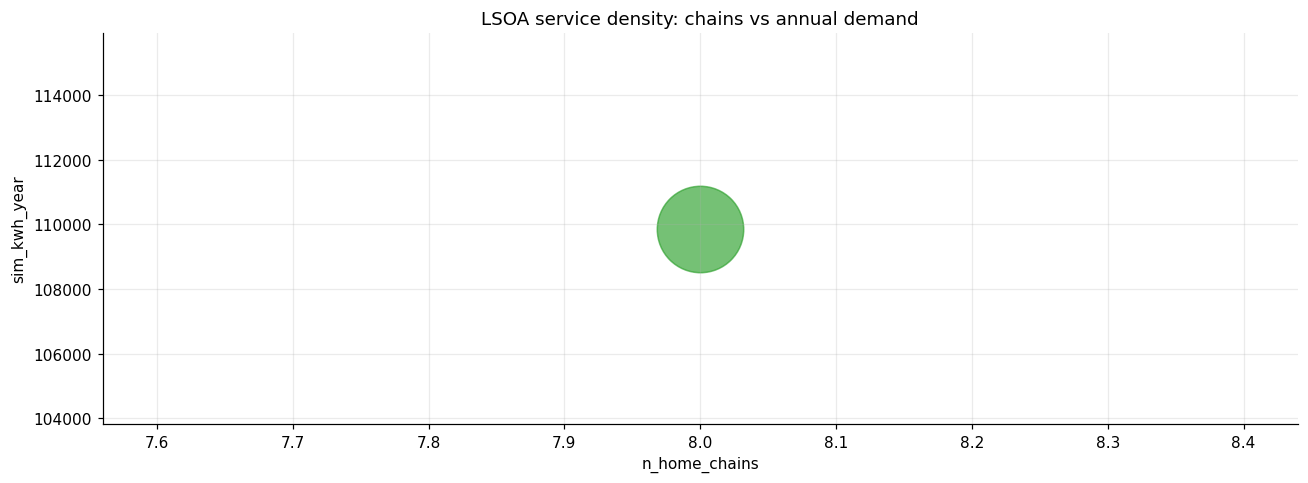

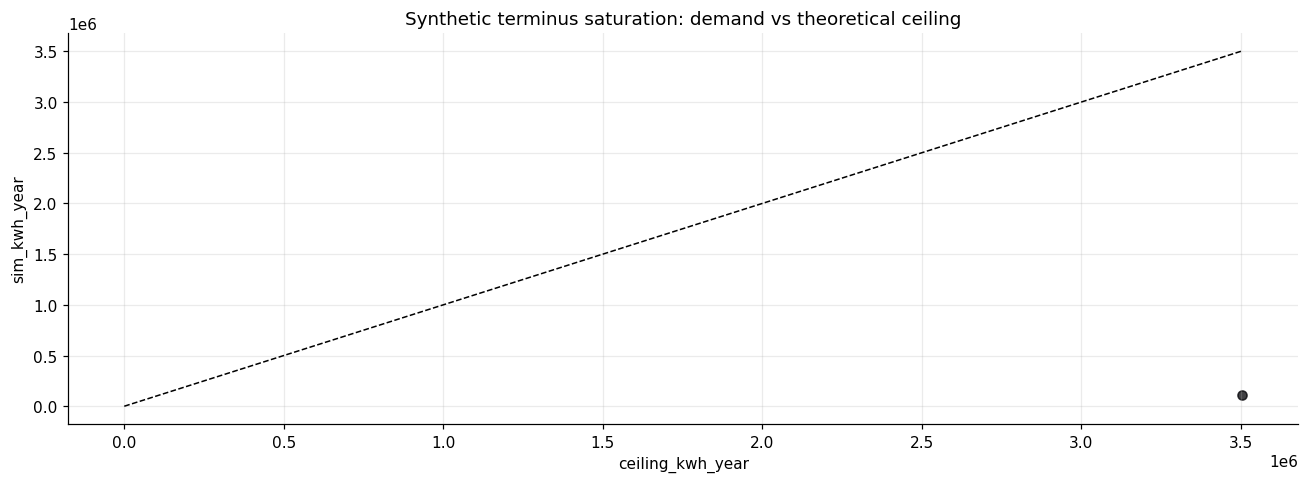

,lsoa_code,n_home_chains,sim_kwh_year,terminus_total_kw,ceiling_kwh_year,gap_ratio
0,unknown,8,109868.233017,400.0,3504000.0,0.031355


In [10]:
home_lsoa = chain_home_lsoa(journeys_smoke, chains_smoke.rename(columns={chain_group_col: "chain_id"}))
lsoa = lsoa_view(per_chain, home_lsoa)
display(lsoa.head(10))

if lsoa.empty:
    display(pd.DataFrame({"note": ["No LSOA attribution rows available for this smoke sample."]}))
else:
    top = lsoa.head(50)
    fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
    ax.bar(top["lsoa_code"], top["sim_kwh_year"], color="tab:blue")
    ax.set(title="Top-50 coach home LSOAs by simulated annual charging energy", xlabel="LSOA code", ylabel="kWh")
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
    size = np.maximum(lsoa["terminus_total_kw"], 1.0) * 8.0
    ax.scatter(lsoa["n_home_chains"], lsoa["sim_kwh_year"], s=size, alpha=0.65, color="tab:green")
    ax.set(title="LSOA service density: chains vs annual demand", xlabel="n_home_chains", ylabel="sim_kwh_year")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
    ax.scatter(lsoa["ceiling_kwh_year"], lsoa["sim_kwh_year"], c=lsoa["gap_ratio"], cmap="magma", alpha=0.75)
    max_axis = max(float(lsoa["ceiling_kwh_year"].max()), float(lsoa["sim_kwh_year"].max()), 1.0)
    ax.plot([0, max_axis], [0, max_axis], color="black", lw=1, ls="--")
    ax.set(title="Synthetic terminus saturation: demand vs theoretical ceiling", xlabel="ceiling_kwh_year", ylabel="sim_kwh_year")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    display(lsoa.sort_values("gap_ratio", ascending=False).head(10))

## F. Honest Labels

本段列出 notebook 中最容易被误读的 modelling labels。它们不是免责声明的装饰，而是读者解释每张图时必须带着的边界条件；后续工程路线见 [`docs/coach_annual_next_steps.md`](../docs/coach_annual_next_steps.md)。

In [11]:
honest_labels = pd.DataFrame(
    [
        ("chain assignment is heuristic", "coach_chain_id comes from first-fit by start_h, not real operator blocking"),
        ("LSOA attribution = mode(end_lsoa)", "home LSOA is post-hoc mode over chain end_lsoa values"),
        ("terminus capacity synthesized", "terminus_total_kw is summed from simulated chain charger ratings"),
        ("no public charger in baseline", "OCM/public charging supply is not included in E.5 baseline"),
        ("no utilization", "ceiling_kwh_year = terminus_total_kw * 8760, with no utilisation coefficient"),
        ("no operator real blocking", "no CPT/DfT/operator roster data are used"),
        ("warm_up_days=0 is smoke-only", f"production annual runs should use WARMUP_DAYS={WARMUP_DAYS}"),
        ("Layover charging policy", "off by default; opt-in at OCM-eligible LSOAs"),
        ("Retry pass", "two-pass when --enable-eligible-layover-retry is set; pass 1 layover-off, pass 2 only at chain LSOAs with Rapid+ OCM public stations"),
        ("feed-year only", f"date window is {COACH_FEED_YEAR_START} to {COACH_FEED_YEAR_END}"),
    ],
    columns=["label", "meaning"],
)
display(honest_labels)

,label,meaning
0,chain assignment is heuristic,coach_chain_id comes from first-fit by start_h...
1,LSOA attribution = mode(end_lsoa),home LSOA is post-hoc mode over chain end_lsoa...
2,terminus capacity synthesized,terminus_total_kw is summed from simulated cha...
3,no public charger in baseline,OCM/public charging supply is not included in ...
4,no utilization,"ceiling_kwh_year = terminus_total_kw * 8760, w..."
5,no operator real blocking,no CPT/DfT/operator roster data are used
6,warm_up_days=0 is smoke-only,production annual runs should use WARMUP_DAYS=14
7,Layover charging policy,off by default; opt-in at OCM-eligible LSOAs
8,Retry pass,two-pass when --enable-eligible-layover-retry ...
9,feed-year only,date window is 2025-12-26 to 2026-12-25


In [12]:
print(f"notebook executed in {time.time() - NOTEBOOK_START:.1f}s")

notebook executed in 5.5s
